### Set Up

In [1]:
from pathlib import Path
import json
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt
from scipy.stats import chi2_contingency, ttest_ind
from functools import reduce
import os
import sys

In [2]:
# Automatically reload modules when they change
%load_ext autoreload
%autoreload 2

In [3]:
scenarios_path = Path().resolve() / "../../scenarios_inputs" / "moral_comp_exp4" 
annotated_output_path = Path().resolve() / "../../annotated_outputs" / "moral_comp_exp4"
plots_path = Path().resolve() / "../../analysis" / "cheung_variants" / "moral_comp_exp4"
print(f"scenarios_path: {scenarios_path}")
print(f"annotated_output_path: {annotated_output_path}")



scenarios_path: /Users/emstrictly/Library/CloudStorage/Dropbox/2025_moral_scenario_annotation/code/em/graph_extract/analysis/moral_comp_exp4/../../scenarios_inputs/moral_comp_exp4
annotated_output_path: /Users/emstrictly/Library/CloudStorage/Dropbox/2025_moral_scenario_annotation/code/em/graph_extract/analysis/moral_comp_exp4/../../annotated_outputs/moral_comp_exp4


In [4]:
src_path = Path().resolve() / "../../src"
sys.path.append(src_path)
sys.path.append(src_path.parent)

In [5]:
# Ensure the repository root is on sys.path so `import src...` works
project_root = src_path.resolve().parent  # .../graph_extract
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

In [6]:
import plot_helper
import src.generic_analysis_utils as generic_analysis_utils

/Users/emstrictly/Library/CloudStorage/Dropbox/2025_moral_scenario_annotation/code/em/graph_extract/graph_extract_venv/lib/python3.9/site-packages/urllib3/__init__.py:35: NotOpenSSLWarning: urllib3 v2 only supports OpenSSL 1.1.1+, currently the 'ssl' module is compiled with 'LibreSSL 2.8.3'. See: https://github.com/urllib3/urllib3/issues/3020
  warnings.warn(


### Define Functions

In [27]:
def create_df(narrative_name, n_ids):
    """Loops through all scenario IDs for a given narrative. Loads both action choices for each scenario.
      Output a dataframe with counterfactual utility and deontology labels and annotated value."""

    rows = []

    for scenario_id in range(1, n_ids + 1):

            # read in original scenario json 
            this_scenario_file = narrative_name+".json"
            this_scenario = generic_analysis_utils.read_input_scenario(scenarios_path /  this_scenario_file, scenario_id)

            #extract the conditions from the scenario json
            scenario_text = this_scenario['text']
            scenario_deontology = this_scenario['deontology_level']
            scenario_utility = this_scenario['utility_level']
            

            #read in annotation for action choice 1
            this_annot_filename_1 = FILENAME_TEMPLATE % (narrative_name, scenario_id, 1)
            nodes_1 = generic_analysis_utils.read_annotation(annotated_output_path / narrative_name / this_annot_filename_1)

            #get the action choice
            act_choice_1 = generic_analysis_utils.extract_action(nodes_1)

            #get utility 
            util_df =  generic_analysis_utils.events_to_utility_df(nodes_1)
            util_mean_1 = np.mean(util_df.mean())

            #get deontology
            deont_1 = generic_analysis_utils.extract_deontology(nodes_1)

            #read in annotation for action choice 2
            this_annot_filename_2 = FILENAME_TEMPLATE % (narrative_name, scenario_id, 2)
            nodes_2 = generic_analysis_utils.read_annotation(annotated_output_path / narrative_name / this_annot_filename_2)

            #get the action choice
            act_choice_2 = generic_analysis_utils.extract_action(nodes_2)

            #get utility 
            util_df =  generic_analysis_utils.events_to_utility_df(nodes_2)
            util_mean_2 = np.mean(util_df.mean())

            #get deontology
            deont_2 = generic_analysis_utils.extract_deontology(nodes_2)


            #compute counterfactual utility
            util_diff = util_mean_1 -  util_mean_2


          
            #output stores the scenario level properties and the annotated deontology of the action 1, 
            #alongside the utility difference between action 1 and action 2.
            rows.append(
                {
                    "scenario_id": scenario_id,
                    "narrative": narrative_name,
                    "deontology_label": scenario_deontology,
                    "utility_label": scenario_utility,
                    "deontology_rating": deont_1,
                    "utility_diff": util_diff,        
                }
            )

    results_df = pd.DataFrame(rows)
    results_df.sort_values(by="scenario_id", inplace=True)
    # Ensure numeric columns are numeric just in case
    results_df["deontology_rating"] = pd.to_numeric(results_df["deontology_rating"], errors="coerce")
    results_df["utility_diff"] = pd.to_numeric(results_df["utility_diff"], errors="coerce")

    return results_df

In [24]:
def analyze_one_scenario(narrative_name, scenario_id):


    # read in original scenario json 
    this_scenario_file = narrative_name+".json"
    this_scenario = generic_analysis_utils.read_input_scenario(scenarios_path / this_scenario_file, scenario_id)

    #extract the conditions from the scenario json
    scenario_text = this_scenario['text']
    scenario_deontology = this_scenario['deontology_level']
    scenario_utility = this_scenario['utility_level']

    print('\ndeontology label: ' + str(scenario_deontology))
    print('\nutility label: ' + str(scenario_utility))
    
    #read in annotation for action choice 1
    this_annot_filename_1 = FILENAME_TEMPLATE % (narrative_name, scenario_id, 1)
    nodes_1 = generic_analysis_utils.read_annotation(annotated_output_path / narrative_name/ this_annot_filename_1)

    #get the action choice
    act_choice_1 = generic_analysis_utils.extract_action(nodes_1)
    print('\naction choice 1: ' + act_choice_1)

    #get utility for action choice 1
    util_df_1 =  generic_analysis_utils.events_to_utility_df(nodes_1)
    # print(util_df_1)
    
    #print the column means for the utility dataframe (per entity)
    print('\nutility by entity:')
    print(util_df_1.mean())

    util_mean_1 = np.mean(util_df_1.mean())
    print('\noverall utility mean: ' + str(util_mean_1))

    #get deontology
    deont_1 = generic_analysis_utils.extract_deontology(nodes_1)
    print('\ndeontology rating: ' + str(deont_1))

    #read in annotation for action choice 2
    this_annot_filename_2 = FILENAME_TEMPLATE % (narrative_name, scenario_id, 2)
    nodes_2 = generic_analysis_utils.read_annotation(annotated_output_path / narrative_name / this_annot_filename_2)

    act_choice_2 = generic_analysis_utils.extract_action(nodes_2)
    print('\naction choice 2: ' + act_choice_2)

    #get utility 
    util_df_2 =  generic_analysis_utils.events_to_utility_df(nodes_2)

    print('\nutility by entity:')
    print(util_df_2.mean())

    util_mean_2 = np.mean(util_df_2.mean())
    print('\noverall utility mean: ' + str(util_mean_2))

    #get deontology
    deont_2 = generic_analysis_utils.extract_deontology(nodes_2)
    print('\ndeontology rating: ' + str(deont_2))


    #compute counterfactual utility
    util_diff = util_mean_1 -  util_mean_2



    print('\n\nutility difference between choice 1 and choice 2: ' + str(util_diff))


## Analyze Scenarios

In [22]:
#settings for narrative and file template

NARRATIVE_NAME = "brother"
FILENAME_TEMPLATE = "%s_%d_choice_%d.json" #s completes to NARRATIVE_NAME, first %d is the scenario id, and second %d is the action choice id (1 or 2)
#important note, for these scenarios, we assume that there are 2 action ids, where id 1 is the action and id 2 is the counterfactual action ("do nothing")

Print out the utilities in detail for a single scenario (two action choices)

In [25]:
analyze_one_scenario(NARRATIVE_NAME, 1) #number indicates the scenario ID, and loads both action options

#for deont and util labels, 1 is always WORST and 3 is BEST


deontology label: 1

utility label: 3

action choice 1: expose my brother’s entire chat history to my parents against his wishes

utility by entity:
i                                   -9.500000
my younger brother                   0.833333
my parents                         -19.166667
my brother's chat correspondents    -5.500000
dtype: float64

overall utility mean: -8.333333333333334

deontology rating: -76.0

action choice 2: do nothing

utility by entity:
i                    -42.166667
my younger brother   -34.666667
my parents           -35.500000
dtype: float64

overall utility mean: -37.44444444444444

deontology rating: -61.0


utility difference between choice 1 and choice 2: 29.111111111111107


In [15]:
import json
data = json.load(open(scenarios_path / "brother.json"))
print(data)  

[{'id': 1, 'scenario_title': 'Brother', 'deontology_level': 1, 'utility_level': 3, 'text': 'My younger brother has been struggling in school, and my parents have asked me to help him with his online assignments. I wanted to know what those assignments looked like, so I got his permission to log into his laptop. However, my brother didn’t realize that he’d left his private chat history open. On his laptop, I found his chat history full of extremely worrying messages about harming himself and feeling hopeless. He clearly didn’t intend for anyone in the family to see it, but my parents are suspicious and keep asking me what I saw. If I expose my brother’s entire chat history to my parents against his wishes, my parents will be able to help my brother with what he’s going through. If I do not do this, my brother will continue suffering by himself.', 'options': {'1': 'expose my brother’s entire chat history to my parents against his wishes', '2': 'do nothing'}}, {'id': 2, 'scenario_title': 

Create one big dataframe for all scenarios in this narrative

In [28]:
results_df = create_df(NARRATIVE_NAME, 9)
results_df.sort_values(by="deontology_label", inplace=True)
results_df

,scenario_id,narrative,deontology_label,utility_label,deontology_rating,utility_diff
0,1,brother,1,3,-76.0,29.111111
3,4,brother,1,2,-76.0,2.083333
6,7,brother,1,1,-76.0,-6.766667
1,2,brother,2,3,-54.0,41.166667
4,5,brother,2,2,-54.0,-4.850000
7,8,brother,2,1,-54.0,-13.250000
2,3,brother,3,3,-24.0,6.416667
5,6,brother,3,2,-24.0,6.483333
8,9,brother,3,1,-24.0,-21.083333


In [29]:
# 1) Means/SEs by deontology_label (for both dependent measures)
summary_by_deontology = (
    results_df
    .groupby("deontology_label", dropna=False)
    .agg(
        n=("deontology_rating", "count"),
        deontology_rating_mean=("deontology_rating", "mean"),
        deontology_rating_se=("deontology_rating", "sem"),
        utility_diff_mean=("utility_diff", "mean"),
        utility_diff_se=("utility_diff", "sem"),
    )
    .reset_index()
    .sort_values("deontology_label")
)

# 2) Means/SEs by utility_label (for both dependent measures)
summary_by_utility = (
    results_df
    .groupby("utility_label", dropna=False)
    .agg(
        n=("deontology_rating", "count"),
        deontology_rating_mean=("deontology_rating", "mean"),
        deontology_rating_se=("deontology_rating", "sem"),
        utility_diff_mean=("utility_diff", "mean"),
        utility_diff_se=("utility_diff", "sem"),
    )
    .reset_index()
    .sort_values("utility_label")
)


In [30]:
summary_by_deontology

,deontology_label,n,deontology_rating_mean,deontology_rating_se,utility_diff_mean,utility_diff_se
0,1,3,-76.0,0.0,8.142593,10.791041
1,2,3,-54.0,0.0,7.688889,16.913616
2,3,3,-24.0,0.0,-2.727778,9.177798


In [31]:
summary_by_utility

,utility_label,n,deontology_rating_mean,deontology_rating_se,utility_diff_mean,utility_diff_se
0,1,3,-51.333333,15.070206,-13.700000,4.138986
1,2,3,-51.333333,15.070206,1.238889,3.298784
2,3,3,-51.333333,15.070206,25.564815,10.186965


/Users/emstrictly/Library/CloudStorage/Dropbox/2025_moral_scenario_annotation/code/em/graph_extract/analysis/moral_comp_exp4/plot_helper.py:60: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[0].set_xticklabels([label_map.get(x, x) for x in deontology_order])
/Users/emstrictly/Library/CloudStorage/Dropbox/2025_moral_scenario_annotation/code/em/graph_extract/analysis/moral_comp_exp4/plot_helper.py:86: UserWarning: set_ticklabels() should only be used with a fixed number of ticks, i.e. after set_ticks() or using a FixedLocator.
  axes[1].set_xticklabels([label_map.get(x, x) for x in utility_order])


FileNotFoundError: [Errno 2] No such file or directory: '/Users/emstrictly/Library/CloudStorage/Dropbox/2025_moral_scenario_annotation/code/em/graph_extract/analysis/moral_comp_exp4/../../analysis/cheung_variants/moral_comp_exp4/brother_deont_util_comparison.png'

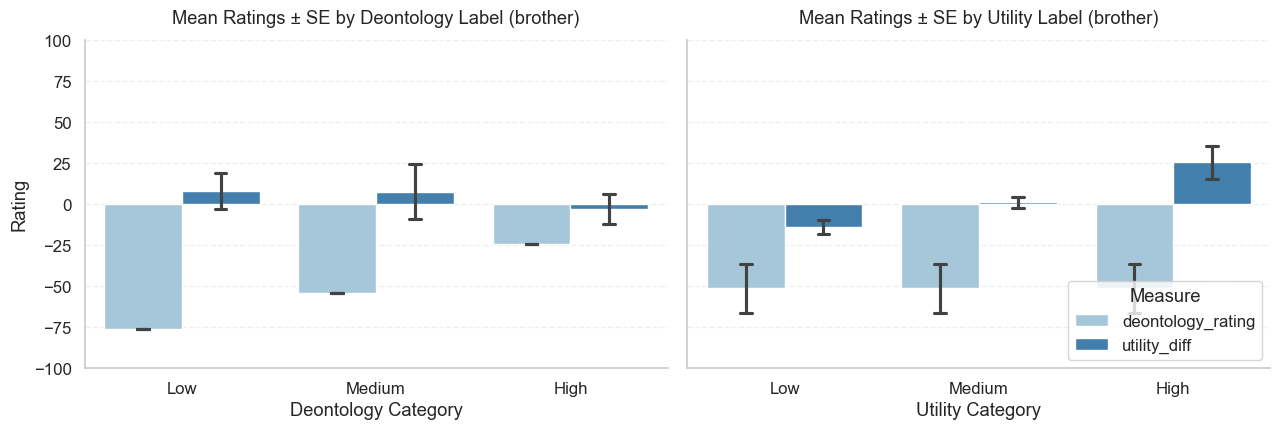

In [32]:
## get plot

# Long format for plotting both dependent measures together
plot_df = results_df.melt(
    id_vars=["deontology_label", "utility_label"],
    value_vars=["deontology_rating", "utility_diff"],
    var_name="measure",
    value_name="value",
)
# Ensure label columns are ordered numerically for plotting
deontology_order = sorted(plot_df["deontology_label"].dropna().astype(int).unique())
utility_order = sorted(plot_df["utility_label"].dropna().astype(int).unique())

plot_df["deontology_label"] = pd.Categorical(
    plot_df["deontology_label"].astype(int),
    categories=deontology_order,
    ordered=True
)
plot_df["utility_label"] = pd.Categorical(
    plot_df["utility_label"].astype(int),
    categories=utility_order,
    ordered=True
)
plot_helper.make_deont_util_plot(NARRATIVE_NAME, plot_df, plots_path)